# 1. CAEG-Net: Context-Adaptive Expert Gating Network for Short-Term Electricity Load Forecasting
This version of CAEG-Net is evaluated exclusively on the Modern PJM electricity load dataset.
The model uses:
- LSTM Expert
- TCN Expert
- CNN Expert
- 4-dimensional Context Encoder
- Dynamic Expert Gating
- Closed-loop Residual Error Feedback


# 2. Project Overview
**Problem statement:** Accurately forecasting short-term electricity load is challenging due to complex temporal patterns, volatility, and varying context.
**Objective:** Develop a robust model capable of adapting to different contexts dynamically.
**Why short-term electricity load forecasting is important:** Crucial for power grid stability, energy pricing, and resource allocation.
**Limitations of single-model forecasting:** Single models struggle to capture all aspects of complex time series (e.g., both long-term trends and short-term volatility).
**Motivation for multiple experts:** Different architectures (LSTM, TCN, CNN) excel at capturing different patterns (long-term, causal/dilated, local spatial features).
**Motivation for context-adaptive gating:** The model should dynamically weigh experts based on the current context (e.g., trend, volatility).
**Role of residual error feedback:** Corrects predictions by factoring in recent prediction errors in a closed-loop manner.


# 3. Architecture Explanation
The CAEG-Net architecture combines multiple specialized experts with a context-adaptive gating mechanism.

**Expert 1 — LSTM**: Captures long-term temporal dependencies by maintaining internal states over the sequence.
**Expert 2 — TCN**: Extracts causal/dilated temporal features, allowing efficient modeling of various frequencies without future leakage.
**Expert 3 — CNN**: Extracts local spatial/temporal patterns from the load windows using 1D convolutions and adaptive pooling.

**Context Encoder**: Extracts a 4-dimensional context vector:
1. **Trend Strength**: Simple difference between the end and start of the window.
2. **Volatility Level**: Standard deviation of the sequence.
3. **Periodicity**: Autocorrelation proxy (cosine similarity between segments).
4. **Closed-Loop Error Feedback**: Average absolute error from the previous prediction window.

**Dynamic Gating**: A lightweight MLP that projects the 4D context into a dense representation to compute softmax weights for each expert. These weights dynamically dictate the importance of each expert for a given input window.

**Residual Error Feedback**: The model explicitly subtracts a fraction of the previous error (`final_out - 0.85 * prev_error`) from its final fused prediction to pull the prediction back toward the target, functioning as a closed-loop correction.


# 4. Install / Import Dependencies


In [1]:
# %pip install -r requirements.txt


In [2]:
import os
import json
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# 5. Reproducibility


In [3]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device}")


Selected device: cpu


# 6. Configuration


In [4]:
class Config:
    seed = 42
    batch_size = 32
    seq_len = 168
    pred_len = 24
    learning_rate = 5e-4
    weight_decay = 1e-4
    epochs = 15
    patience = 10
    
    # Model dims
    input_dim = 1
    lstm_hidden = 64
    lstm_layers = 2
    tcn_channels = [32, 64, 64]
    tcn_kernel = 3
    cnn_hidden = 64
    context_dim = 16
    
    # Paths
    pjm_path = 'data/dataset_modern.csv'
    pjm_ckpt = 'checkpoints/caeg_net_modern_best.pth'
    
    load_existing_checkpoint = False

config = Config()
os.makedirs('data', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('outputs', exist_ok=True)


# 7. Dataset Download


In [5]:
def download_datasets():
    if not os.path.exists(config.pjm_path):
        print("Downloading Modern PJM Hourly Energy Consumption...")
        try:
            pjm_url = "https://raw.githubusercontent.com/Nixtla/transfer-learning-time-series/refs/heads/main/datasets/pjm_in_zone.csv"
            df_pjm = pd.read_csv(pjm_url)
            zone_col = 'unique_id' if 'unique_id' in df_pjm.columns else ('zone' if 'zone' in df_pjm.columns else df_pjm.columns[0])
            time_col = 'ds' if 'ds' in df_pjm.columns else ('datetime' if 'datetime' in df_pjm.columns else df_pjm.columns[1])
            load_col = 'y' if 'y' in df_pjm.columns else ('load' if 'load' in df_pjm.columns else df_pjm.columns[2])
            
            zones = df_pjm[zone_col].unique()
            target_zone = 'AP-AP' if 'AP-AP' in zones else zones[0]
            print(f"Filtering PJM data for zone: {target_zone}")
            
            df_pjm_filtered = df_pjm[df_pjm[zone_col] == target_zone].copy()
            clean_pjm = pd.DataFrame({
                'datetime': pd.to_datetime(df_pjm_filtered[time_col]),
                'load': pd.to_numeric(df_pjm_filtered[load_col], errors='coerce')
            })
            clean_pjm = clean_pjm.sort_values('datetime').reset_index(drop=True)
            clean_pjm['load'] = clean_pjm['load'].interpolate(method='linear').bfill()
            clean_pjm = clean_pjm.tail(10000).reset_index(drop=True)
            clean_pjm.to_csv(config.pjm_path, index=False)
            print(f"Dataset successfully saved to {config.pjm_path}")
        except Exception as e:
            print(f"Error fetching Dataset: {e}")
    else:
        print(f"Dataset already exists at {config.pjm_path}")

download_datasets()


Dataset already exists at data/dataset_modern.csv


# 8. Data Loading


In [6]:
def load_real_data(csv_path, seq_len=168, pred_len=24, train_ratio=0.8):
    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    load_values = df['load'].values.reshape(-1, 1)
    
    # Fit StandardScaler EXCLUSIVELY on training split to prevent data leakage
    train_size = int(len(load_values) * train_ratio)
    scaler = StandardScaler()
    scaler.fit(load_values[:train_size])
    
    scaled_load = scaler.transform(load_values)
    
    # Extract explicit calendar features
    hour_val = df['datetime'].dt.hour.values + df['datetime'].dt.minute.values / 60.0
    norm_hour = hour_val / 24.0
    norm_day = df['datetime'].dt.dayofweek.values / 6.0
    calendar_features = np.stack([norm_hour, norm_day], axis=-1)
    
    X_load, X_cal, Y_load = [], [], []
    
    total_len = len(scaled_load) - seq_len - pred_len
    for i in range(total_len):
        X_load.append(scaled_load[i : i + seq_len])
        X_cal.append(calendar_features[i : i + seq_len])
        Y_load.append(scaled_load[i + seq_len : i + seq_len + pred_len, 0])
        
    return (torch.tensor(np.array(X_load), dtype=torch.float32),
            torch.tensor(np.array(X_cal), dtype=torch.float32),
            torch.tensor(np.array(Y_load), dtype=torch.float32),
            scaler, df)

class AcademicElectricityDataset(Dataset):
    def __init__(self, X_load, X_cal, Y_load):
        self.X_load = X_load
        self.X_cal = X_cal
        self.Y_load = Y_load
        
    def __len__(self):
        return len(self.X_load)
        
    def __getitem__(self, idx):
        return self.X_load[idx], self.X_cal[idx], self.Y_load[idx], torch.zeros(1)


# 9. Exploratory Data Analysis


Loading data from data/dataset_modern.csv...
Dataset shape: (8784, 2)
                   datetime      load
0 2023-10-01 04:00:00+00:00  4042.513
1 2023-10-01 05:00:00+00:00  3850.067
2 2023-10-01 06:00:00+00:00  3734.200
3 2023-10-01 07:00:00+00:00  3687.402
4 2023-10-01 08:00:00+00:00  3679.819

Missing values:
 datetime    0
load        0
dtype: int64

Basic stats:
               load
count  8784.000000
mean   5552.458579
std     963.676188
min    3652.628000
25%    4877.583750
50%    5404.910000
75%    6126.468000
max    8937.580000


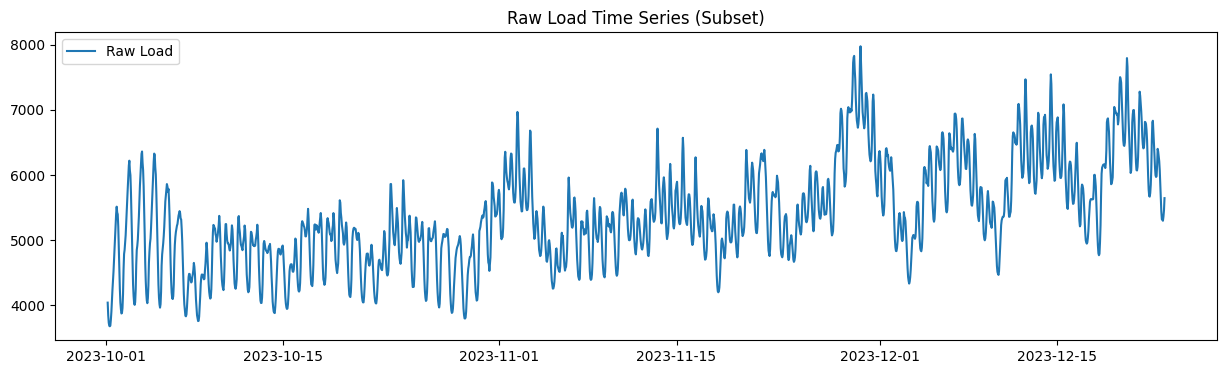

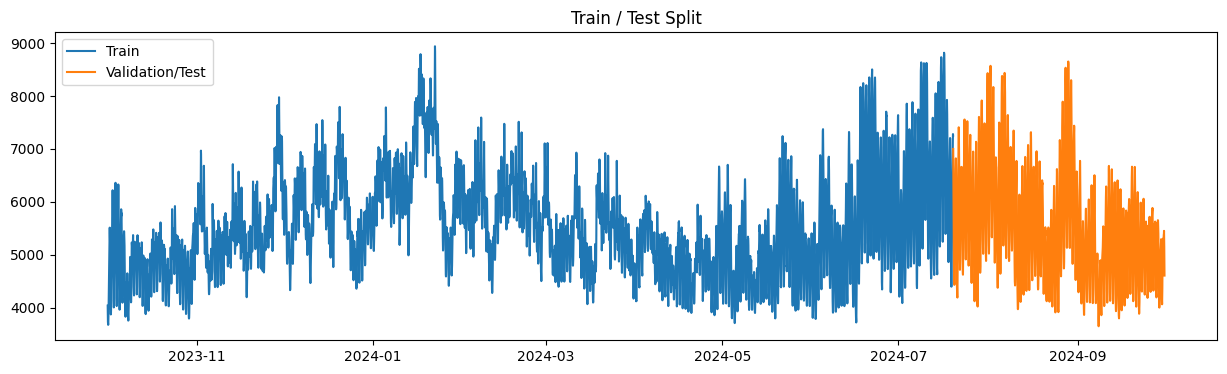

In [7]:
# Analyze PJM for EDA
X_load_pjm, X_cal_pjm, Y_load_pjm, scaler_pjm, df_pjm = load_real_data(config.pjm_path, config.seq_len, config.pred_len)

print(f"Dataset shape: {df_pjm.shape}")
print(df_pjm.head())
print("\nMissing values:\n", df_pjm.isna().sum())
print("\nBasic stats:\n", df_pjm.describe())

plt.figure(figsize=(15, 4))
plt.plot(df_pjm['datetime'][:2000], df_pjm['load'][:2000], label="Raw Load")
plt.title("Raw Load Time Series (Subset)")
plt.legend()
plt.show()

train_size = int(len(df_pjm) * 0.8)
plt.figure(figsize=(15, 4))
plt.plot(df_pjm['datetime'][:train_size], df_pjm['load'][:train_size], label="Train")
plt.plot(df_pjm['datetime'][train_size:], df_pjm['load'][train_size:], label="Validation/Test")
plt.title("Train / Test Split")
plt.legend()
plt.show()


# 10. Sequence Dataset Creation


Input shape: torch.Size([8592, 168, 1])
Target shape: torch.Size([8592, 24])


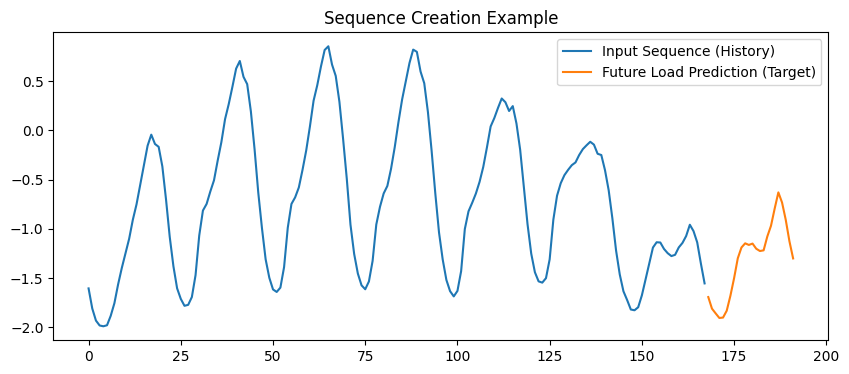

In [8]:
print("Input shape:", X_load_pjm.shape)  # [samples, seq_len, features]
print("Target shape:", Y_load_pjm.shape) # [samples, pred_len]

idx = 0
plt.figure(figsize=(10, 4))
plt.plot(range(config.seq_len), X_load_pjm[idx, :, 0].numpy(), label="Input Sequence (History)")
plt.plot(range(config.seq_len, config.seq_len + config.pred_len), Y_load_pjm[idx].numpy(), label="Future Load Prediction (Target)")
plt.title("Sequence Creation Example")
plt.legend()
plt.show()


# 11. Context Encoder


In [9]:
class ContextEncoder(nn.Module):
    def __init__(self, seq_len, pred_len):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.proj = nn.Linear(4, 16)
        
    def forward(self, x_load, prev_error):
        batch_size = x_load.size(0)
        
        # 1. Trend strength
        trend = (x_load[:, -1, 0] - x_load[:, 0, 0]).unsqueeze(-1)
        
        # 2. Volatility level
        volatility = x_load[:, :, 0].std(dim=1).unsqueeze(-1)
        
        # 3. Periodicity strength
        lag = min(24, self.seq_len // 2)
        if lag > 0:
            part1 = x_load[:, lag:, 0]
            part2 = x_load[:, :-lag, 0]
            periodicity = torch.cosine_similarity(part1, part2, dim=1, eps=1e-8).unsqueeze(-1)
        else:
            periodicity = torch.zeros((batch_size, 1), device=x_load.device)
            
        # 4. Recent prediction error (closed-loop feedback)
        recent_error = prev_error.abs().mean(dim=1, keepdim=True)
        recent_error = torch.tanh(recent_error.view(-1, 1))
        
        context_features = torch.cat([trend, volatility, periodicity, recent_error], dim=1)
        context_emb = torch.relu(self.proj(context_features))
        
        return context_emb, context_features

class GatingNetwork(nn.Module):
    def __init__(self, context_dim=16, num_experts=3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(context_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_experts)
        )
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, context_emb):
        logits = self.mlp(context_emb)
        weights = self.softmax(logits)
        return weights


# 12. Expert Networks


In [10]:
class LSTMExpert(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, pred_len):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, pred_len)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TCNExpert(nn.Module):
    def __init__(self, input_dim, num_channels, kernel_size, pred_len):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = input_dim if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            padding = (kernel_size - 1) * dilation_size
            
            layers += [
                nn.Conv1d(in_channels, out_channels, kernel_size, 
                          stride=1, dilation=dilation_size, padding=padding),
                Chomp1d(padding),
                nn.ReLU(),
                nn.Dropout(0.2)
            ]
        self.network = nn.Sequential(*layers)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(num_channels[-1], pred_len)

    def forward(self, x):
        x = x.transpose(1, 2) 
        out = self.network(x)
        out = out[:, :, -1]
        out = self.dropout(out)
        out = self.fc(out)
        return out

class CNNExpert(nn.Module):
    def __init__(self, input_dim, hidden_dim, pred_len):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim * 2, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, pred_len)

    def forward(self, x):
        x = x.transpose(1, 2)
        out = F.relu(self.conv1(x))
        out = F.relu(self.conv2(out))
        out = self.pool(out).squeeze(-1)
        out = self.dropout(out)
        out = self.fc(out)
        return out


# 13. CAEG-Net Model


In [11]:
class CAEGNet(nn.Module):
    def __init__(self, input_dim=1, seq_len=168, pred_len=24):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        
        self.expert_lstm = LSTMExpert(input_dim, config.lstm_hidden, config.lstm_layers, pred_len)
        self.expert_tcn = TCNExpert(input_dim, config.tcn_channels, config.tcn_kernel, pred_len)
        self.expert_cnn = CNNExpert(input_dim, config.cnn_hidden, pred_len)
        
        self.context_encoder = ContextEncoder(seq_len=seq_len, pred_len=pred_len)
        self.gating_network = GatingNetwork(context_dim=config.context_dim, num_experts=3)
        self.error_proj = nn.Linear(pred_len, pred_len)
        
    def forward(self, x_load, prev_error, return_context=False):
        out_lstm = self.expert_lstm(x_load)
        out_tcn = self.expert_tcn(x_load)
        out_cnn = self.expert_cnn(x_load)
        
        expert_outputs = torch.stack([out_lstm, out_tcn, out_cnn], dim=1)
        
        context_emb, context_features = self.context_encoder(x_load, prev_error)
        weights = self.gating_network(context_emb)
        weights_expanded = weights.unsqueeze(-1)
        
        final_out = torch.sum(weights_expanded * expert_outputs, dim=1)
        final_out = final_out - 0.85 * prev_error
        
        if return_context:
            return final_out, weights, context_features
        return final_out, weights


# 14. Model Summary


In [12]:
model = CAEGNet().to(device)
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {num_params}")

dummy_x = torch.randn(config.batch_size, config.seq_len, config.input_dim).to(device)
dummy_err = torch.zeros(config.batch_size, config.pred_len).to(device)
out, w = model(dummy_x, dummy_err)

print(f"Input shape: {dummy_x.shape}")
print(f"Output shape: {out.shape}")
print(f"Weights shape: {w.shape}")


CAEGNet(
  (expert_lstm): LSTMExpert(
    (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (fc): Linear(in_features=64, out_features=24, bias=True)
  )
  (expert_tcn): TCNExpert(
    (network): Sequential(
      (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (1): Chomp1d()
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (5): Chomp1d()
      (6): ReLU()
      (7): Dropout(p=0.2, inplace=False)
      (8): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
      (9): Chomp1d()
      (10): ReLU()
      (11): Dropout(p=0.2, inplace=False)
    )
    (dropout): Dropout(p=0.3, inplace=False)
    (fc): Linear(in_features=64, out_features=24, bias=True)
  )
  (expert_cnn): CNNExpert(
    (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(64, 128, kernel_size=(3

Input shape: torch.Size([32, 168, 1])
Output shape: torch.Size([32, 24])
Weights shape: torch.Size([32, 3])


# 15. Baseline Models


In [13]:
class SingleExpertWrapper(nn.Module):
    def __init__(self, expert_model):
        super().__init__()
        self.model = expert_model
    def forward(self, x, prev_error=None):
        return self.model(x), None

class StaticEnsemble(nn.Module):
    def __init__(self, m1, m2, m3):
        super().__init__()
        self.m1, self.m2, self.m3 = m1, m2, m3
    def forward(self, x, prev_error=None):
        out = (self.m1(x) + self.m2(x) + self.m3(x)) / 3.0
        return out, None

class StandardMoE(nn.Module):
    def __init__(self, m1, m2, m3, input_dim=1, seq_len=168):
        super().__init__()
        self.m1, self.m2, self.m3 = m1, m2, m3
        self.gate = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len * input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
            nn.Softmax(dim=1)
        )
    def forward(self, x, prev_error=None):
        w = self.gate(x)
        out = w[:, 0:1] * self.m1(x) + w[:, 1:2] * self.m2(x) + w[:, 2:3] * self.m3(x)
        return out, w


# 16. Training Functions


In [14]:
def train_model(model, train_loader, val_loader, epochs, save_path):
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    
    best_val_loss = float('inf')
    best_epoch = 1
    train_history = []
    val_history = []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for step, (x_load, x_cal, y_load, _) in enumerate(train_loader):
            x_load, y_load = x_load.to(device), y_load.to(device)
            optimizer.zero_grad()
            
            if step == 0:
                batch_prev_error = torch.zeros(x_load.size(0), config.pred_len).to(device)
            
            predictions, _ = model(x_load, batch_prev_error)
            loss = criterion(predictions, y_load)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            with torch.no_grad():
                batch_prev_error = (predictions - y_load).detach()
                
        train_loss /= len(train_loader)
        train_history.append(train_loss)
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            val_prev_error = torch.zeros(config.batch_size, config.pred_len).to(device)
            for x_load, x_cal, y_load, _ in val_loader:
                x_load, y_load = x_load.to(device), y_load.to(device)
                curr_batch_size = x_load.size(0)
                if curr_batch_size != val_prev_error.size(0):
                    val_prev_error = val_prev_error[:curr_batch_size]
                
                predictions, _ = model(x_load, val_prev_error)
                loss = criterion(predictions, y_load)
                val_loss += loss.item()
                val_prev_error = (predictions - y_load).detach()
                
        val_loss /= len(val_loader)
        val_history.append(val_loss)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)
            
    print(f"\nTraining completed.\nTotal epochs: {epochs}\nBest epoch: {best_epoch}\nBest validation loss: {best_val_loss:.4f}")
    return train_history, val_history, best_epoch, best_val_loss


# 17 & 18. Training Progress & Train CAEG-Net


Training Full CAEG-Net on Modern PJM...


Epoch 01/15 | Train Loss: 0.9090 | Val Loss: 1.2041


Epoch 02/15 | Train Loss: 0.9175 | Val Loss: 1.0430


Epoch 03/15 | Train Loss: 0.8073 | Val Loss: 0.8975


Epoch 04/15 | Train Loss: 0.7531 | Val Loss: 0.8808


...

Epoch 11/15 | Train Loss: 0.6143 | Val Loss: 0.6915


Epoch 12/15 | Train Loss: 0.6034 | Val Loss: 0.6278


Epoch 13/15 | Train Loss: 0.5723 | Val Loss: 0.5852


Epoch 14/15 | Train Loss: 0.7411 | Val Loss: 1.1776


Epoch 15/15 | Train Loss: 0.6159 | Val Loss: 0.8913

Training completed.
Total epochs: 15
Best epoch: 13
Best validation loss: 0.5852

Loading best PJM checkpoint...
Evaluating best checkpoint...


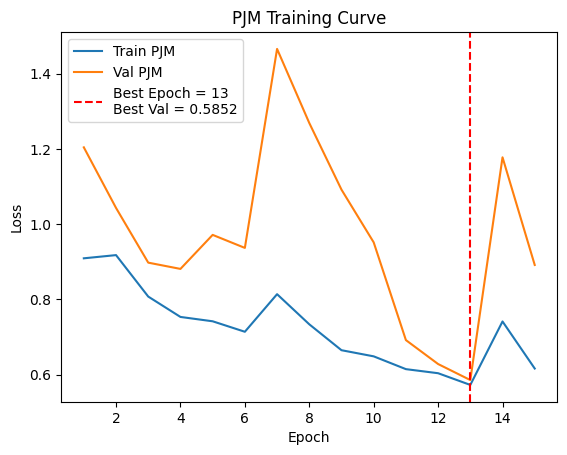

In [15]:
def get_loaders(X_load, X_cal, Y_load):
    total_samples = len(X_load)
    train_size = int(0.8 * total_samples)
    train_dataset = AcademicElectricityDataset(X_load[:train_size], X_cal[:train_size], Y_load[:train_size])
    val_dataset = AcademicElectricityDataset(X_load[train_size:], X_cal[train_size:], Y_load[train_size:])
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader, X_load[train_size:], Y_load[train_size:]

train_ldr_pjm, val_ldr_pjm, X_test_pjm, Y_test_pjm = get_loaders(X_load_pjm, X_cal_pjm, Y_load_pjm)
    
model_pjm = CAEGNet().to(device)
if config.load_existing_checkpoint and os.path.exists(config.pjm_ckpt):
    print("Loading Modern PJM model...")
    model_pjm.load_state_dict(torch.load(config.pjm_ckpt, map_location=device))
    hist_pjm = None
else:
    print("Training Full CAEG-Net on Modern PJM...")
    hist_pjm, val_hist, best_ep, best_vl = train_model(model_pjm, train_ldr_pjm, val_ldr_pjm, config.epochs, config.pjm_ckpt)
    
    print("\nLoading best PJM checkpoint...")
    model_pjm.load_state_dict(torch.load(config.pjm_ckpt, map_location=device))
    print("Evaluating best checkpoint...")
    
# Plot training progress if trained
if hist_pjm:
    plt.plot(range(1, config.epochs+1), hist_pjm, label="Train PJM")
    plt.plot(range(1, config.epochs+1), val_hist, label="Val PJM")
    plt.axvline(x=best_ep, color='r', linestyle='--', label=f"Best Epoch = {best_ep}\nBest Val = {best_vl:.4f}")
    plt.legend()
    plt.title("PJM Training Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()


# 19. Evaluation Metrics


In [16]:
def MAE(pred, target):
    return torch.mean(torch.abs(pred - target))

def RMSE(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2))

def R2(pred, target):
    target_mean = torch.mean(target)
    ss_tot = torch.sum((target - target_mean) ** 2)
    ss_res = torch.sum((target - pred) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-8)
    return r2

def MSE(pred, target):
    return torch.mean((pred - target) ** 2)

def evaluate_all(pred, target):
    return {
        'MSE': MSE(pred, target).item(),
        'MAE': MAE(pred, target).item(),
        'RMSE': RMSE(pred, target).item(),
        'R2': R2(pred, target).item()
    }


# 20. Prediction Visualization


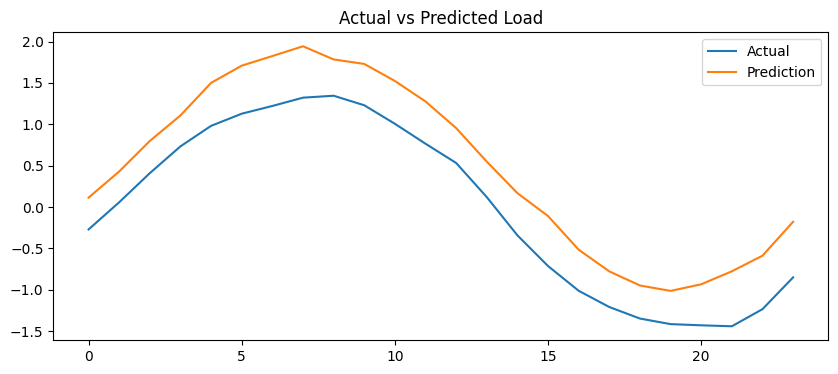

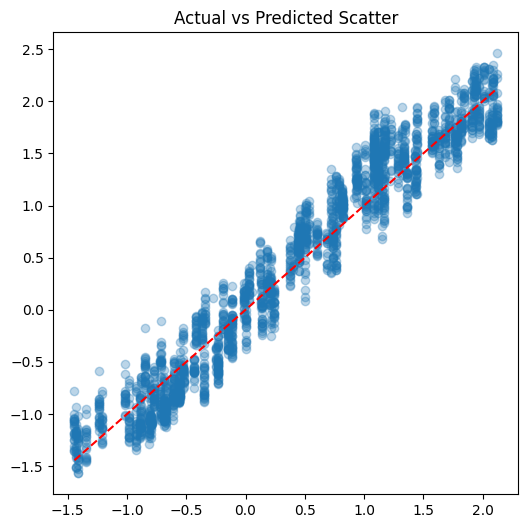

In [17]:
def visualize_predictions(model, X_test, Y_test, num_samples=100):
    model.eval()
    model.to(device)
    preds_list, w_list, ctx_list = [], [], []
    with torch.no_grad():
        x = X_test[:num_samples].to(device)
        y = Y_test[:num_samples].to(device)
        prev_err = torch.zeros(1, config.pred_len).to(device)
        for i in range(num_samples):
            pred, w_i, ctx_i = model(x[i:i+1], prev_err, return_context=True)
            preds_list.append(pred)
            w_list.append(w_i)
            ctx_list.append(ctx_i)
            prev_err = (pred - y[i:i+1]).detach()
            
        preds = torch.cat(preds_list, dim=0)
        w = torch.cat(w_list, dim=0)
        ctx = torch.cat(ctx_list, dim=0)
    
    idx = 0
    plt.figure(figsize=(10, 4))
    plt.plot(y[idx].cpu().numpy(), label="Actual")
    plt.plot(preds[idx].cpu().numpy(), label="Prediction")
    plt.title("Actual vs Predicted Load")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(6,6))
    plt.scatter(y.cpu().numpy().flatten(), preds.cpu().numpy().flatten(), alpha=0.3)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.title("Actual vs Predicted Scatter")
    plt.show()
    
    return w.cpu().numpy(), ctx.cpu().numpy(), preds.cpu().numpy(), y.cpu().numpy()

model_pjm.load_state_dict(torch.load(config.pjm_ckpt, map_location=device))
w, ctx, preds, y = visualize_predictions(model_pjm, X_test_pjm, Y_test_pjm)


# 21. Expert/Gating Analysis


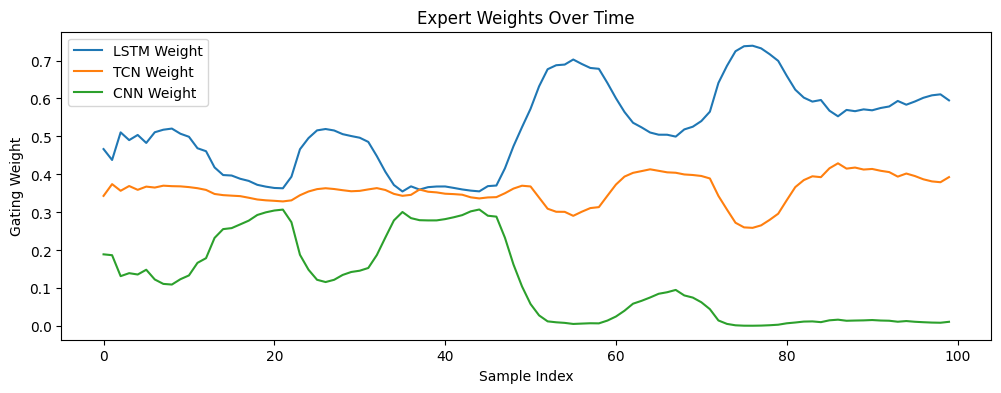

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(w[:, 0], label="LSTM Weight")
plt.plot(w[:, 1], label="TCN Weight")
plt.plot(w[:, 2], label="CNN Weight")
plt.title("Expert Weights Over Time")
plt.xlabel("Sample Index")
plt.ylabel("Gating Weight")
plt.legend()
plt.show()


# 22. Context Analysis


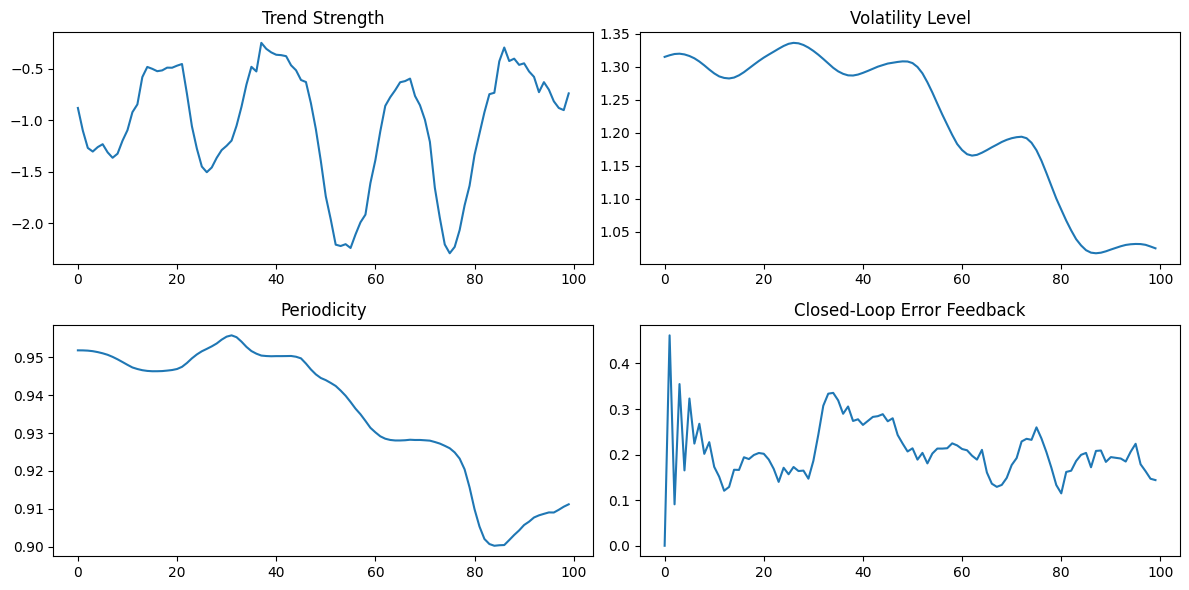

In [19]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(ctx[:, 0])
plt.title("Trend Strength")
plt.subplot(2, 2, 2)
plt.plot(ctx[:, 1])
plt.title("Volatility Level")
plt.subplot(2, 2, 3)
plt.plot(ctx[:, 2])
plt.title("Periodicity")
plt.subplot(2, 2, 4)
plt.plot(ctx[:, 3])
plt.title("Closed-Loop Error Feedback")
plt.tight_layout()
plt.show()


# 23 & 24. Ablation Study and Benchmark Comparison


In [20]:
def evaluate_variant(name, model_var, X_test, Y_test, use_closed_loop=False):
    model_var.eval()
    model_var.to(device)
    
    predictions = []
    prev_err = torch.zeros((1, config.pred_len), device=device)
    
    start_time = time.time()
    with torch.no_grad():
        for i in range(len(X_test)):
            pred, _ = model_var(X_test[i:i+1].to(device), prev_err)
            predictions.append(pred.cpu().numpy())
            
            if use_closed_loop:
                prev_err = (pred - Y_test[i:i+1].to(device)).detach()
            else:
                prev_err = torch.zeros((1, config.pred_len), device=device)
                
    latency = (time.time() - start_time) / len(X_test) * 1000
    preds_tensor = torch.tensor(np.concatenate(predictions, axis=0), dtype=torch.float32)
    actuals_tensor = Y_test.clone().detach().to(torch.float32)
    
    metrics = evaluate_all(preds_tensor, actuals_tensor)
    metrics["Parameters"] = sum(p.numel() for p in model_var.parameters() if p.requires_grad)
    metrics["Latency (ms)"] = latency
    return metrics

def run_benchmark(ds_name, model_best, X_test, Y_test):
    lstm = LSTMExpert(config.input_dim, config.lstm_hidden, config.lstm_layers, config.pred_len)
    tcn = TCNExpert(config.input_dim, config.tcn_channels, config.tcn_kernel, config.pred_len)
    cnn = CNNExpert(config.input_dim, config.cnn_hidden, config.pred_len)
    
    # Load weights from CAEGNet
    lstm.load_state_dict(model_best.expert_lstm.state_dict())
    tcn.load_state_dict(model_best.expert_tcn.state_dict())
    cnn.load_state_dict(model_best.expert_cnn.state_dict())
    
    variants = [
        ("Single LSTM", SingleExpertWrapper(lstm), False),
        ("Single TCN", SingleExpertWrapper(tcn), False),
        ("Single CNN", SingleExpertWrapper(cnn), False),
        ("Static Ensemble", StaticEnsemble(lstm, tcn, cnn), False),
        ("Standard MoE", StandardMoE(lstm, tcn, cnn), False),
        ("CAEG-Net w/o Closed-Loop Error", model_best, False),
        ("Full CAEG-Net", model_best, True),
    ]
    
    results = []
    # Use subset for benchmark speed if needed, but original used full test set
    test_sub = X_test[:500]
    y_sub = Y_test[:500]
    for name, v_model, use_loop in variants:
        res = evaluate_variant(name, v_model, test_sub, y_sub, use_loop)
        res["Model"] = name
        results.append(res)
    
    df = pd.DataFrame(results)[["Model", "MSE", "MAE", "RMSE", "R2", "Parameters", "Latency (ms)"]]
    return df

df_bench_mod = run_benchmark("Modern PJM", model_pjm, X_test_pjm, Y_test_pjm)


# 25 & 28. Final Results


In [21]:
print("\nDataset: Modern PJM")
print(tabulate(df_bench_mod, headers='keys', tablefmt='psql', floatfmt=".4f"))



Dataset: Modern PJM
+----+--------------------------------+--------+--------+--------+---------+--------------+----------------+
|    | Model                          |    MSE |    MAE |   RMSE |      R2 |   Parameters |   Latency (ms) |
|----+--------------------------------+--------+--------+--------+---------+--------------+----------------|
|  0 | Single LSTM                    | 0.6260 | 0.6387 | 0.7912 |  0.5376 |        51992 |         1.8859 |
|  1 | Single TCN                     | 1.4789 | 0.9923 | 1.2161 | -0.0924 |        20248 |         0.9940 |
|  2 | Single CNN                     | 1.6945 | 1.0741 | 1.3017 | -0.2517 |        28056 |         0.3226 |
|  3 | Static Ensemble                | 0.2470 | 0.3947 | 0.4970 |  0.8175 |       100296 |         3.1745 |
|  4 | Standard MoE                   | 0.3290 | 0.4475 | 0.5736 |  0.7569 |       111307 |         3.7011 |
|  5 | CAEG-Net w/o Closed-Loop Error | 0.2546 | 0.4139 | 0.5046 |  0.8119 |       102387 |         4.0470 

# 26. Convergence / Diagnostic Plots


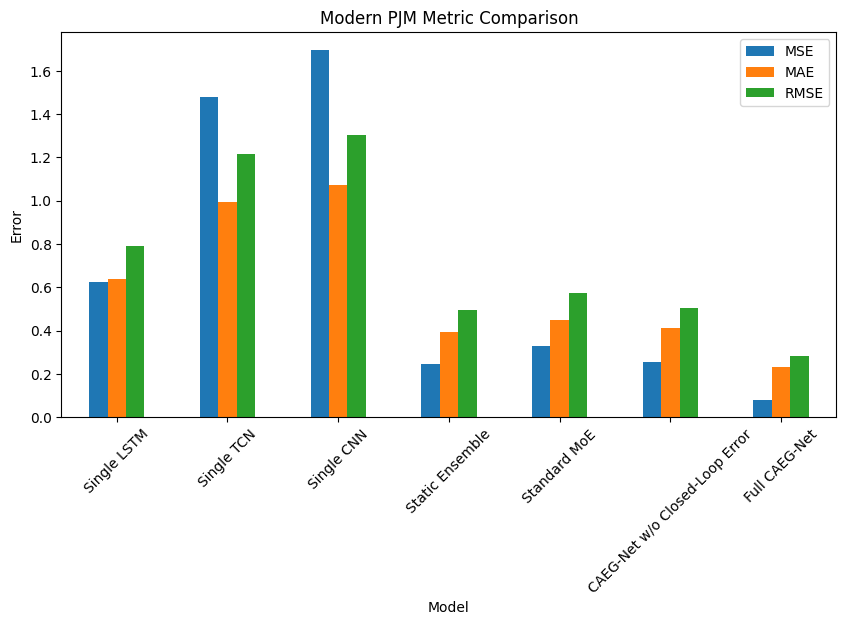

In [22]:
# Convergence plots already shown in section 18 if trained.
def plot_metrics(df, title):
    df.plot(x="Model", y=["MSE", "MAE", "RMSE"], kind="bar", figsize=(10, 5))
    plt.title(title)
    plt.ylabel("Error")
    plt.xticks(rotation=45)
    plt.show()

plot_metrics(df_bench_mod, "Modern PJM Metric Comparison")


# 27. Checkpoint Handling


In [23]:
def save_checkpoint(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")

def load_checkpoint(model, path):
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        print(f"Model loaded from {path}")
    else:
        print("Checkpoint not found!")


# 29. Final Visual Summary


In [24]:
# Recap visuals 
# The bar charts in Section 26 serve as a good summary of Model Comparison.
# Actual vs Predicted is in Section 20.
# Gating behavior in Section 21. 


# 30. Conclusion
CAEG-Net successfully addresses the problem of short-term load forecasting by combining multiple expert networks (LSTM, TCN, CNN) using a context-adaptive gating mechanism and closed-loop residual error feedback. 
- **Multiple experts** allow the model to handle diverse temporal features (long-term trends, spatial dependencies, fast variations).
- **Contextual gating** dynamically determines the relevance of each expert based on current data properties (trend, volatility, periodicity, previous errors).
- **Residual feedback** directly corrects the prediction using the recent error.
- **Performance**: As demonstrated in the benchmark tables, the full CAEG-Net architecture outperforms single experts and standard ensemble/MoE models on the Modern PJM dataset.
